# Laboratorio 7
Melisa Mendizabal - Renato Rojas 


## 0. Configuración y carga de datos

In [1]:
import sys; print(sys.version)
import gensim.downloader as api
from gensim.test.utils import datapath
print("ok")

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
ok


In [2]:
import re, string, math, time, unicodedata
from collections import Counter
from functools import lru_cache
from array import array

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset
import gensim.downloader as api
from gensim.test.utils import datapath

SEED = 42
MAX_LINES = None        # None = corpus completo. Ej: 200_000 para pruebas rápidas
WINDOW = 5              # ventana de contexto (C) para skip-gram
MIN_COUNT = 5           # umbral final de frecuencia mínima
SUBSAMPLING_T = 1e-5    # umbral t de Mikolov et al. (2013)

corpus = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")
news = load_dataset("fancyzhx/ag_news")
glove = api.load("glove-wiki-gigaword-100")

# Benchmarks (se usarán en las siguientes partes)
analogias = datapath("questions-words.txt")
wordsim = datapath("wordsim353.tsv")
simlex = datapath("simlex999.txt")

print(corpus)

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-103-raw-v1/test-00000-of-00001.(…): downloading bytes:           |  0.00B            

wikitext-103-raw-v1/train-00000-of-00002(…): reconstructing file:   0%|          |  0.00B /  157MB            

wikitext-103-raw-v1/train-00000-of-00002(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

[==================================================] 100.0% 128.1/128.1MB downloaded
DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


## 1. Tamaño del corpus: artículos, líneas y tokens

En WikiText, cada fila del dataset es una línea del archivo original. Los títulos de artículo (nivel 1) tienen la forma `" = Título = "`, y las secciones usan `" = = Sección = = "`. Contamos los artículos con los encabezados de nivel 1. Los tokens "crudos" son los separados por espacios (WikiText ya viene pre-tokenizado por espacios).

In [3]:
def corpus_stats(split):
    lines = corpus[split]["text"]
    n_lines = len(lines)
    n_nonempty = 0
    n_articles = 0
    n_tokens = 0
    for l in lines:
        s = l.strip()
        if not s:
            continue
        n_nonempty += 1
        if s.startswith("= ") and s.endswith(" ="):
            # encabezado: nivel 1 si NO empieza con "= ="
            if not s.startswith("= ="):
                n_articles += 1
        n_tokens += len(s.split())
    return dict(split=split, filas_lineas=n_lines, lineas_no_vacias=n_nonempty,
                articulos=n_articles, tokens_crudos=n_tokens)

stats = pd.DataFrame([corpus_stats(s) for s in ["train", "validation", "test"]])
stats.loc["total"] = stats.sum(numeric_only=True)
stats.loc["total", "split"] = "total"
stats

,split,filas_lineas,lineas_no_vacias,articulos,tokens_crudos
0,train,1801350.0,1165029.0,29444.0,101425671.0
1,validation,3760.0,2461.0,60.0,213886.0
2,test,4358.0,2891.0,62.0,241211.0
total,total,1809468.0,1170381.0,29566.0,101880768.0


## 2. Normalización

**Decisiones y justificación**

- Minúsculas: Sí (`str.lower()`), `glove-wiki-gigaword-100` es *uncased*. Si el vocabulario propio distingue "The"/"the", habría tokens sin equivalente en GloVe y la comparación no sería justa. También reduce la dispersión de estadísticas.
- Marcadores de WikiText (`@-@`, `@,@`, `@.@`): Se revierten: Son un artefacto del dataset; GloVe sí contiene tokens como `well-known`, `1,000`, `2.5`. 
- Números: Se conservan tal cual (sin mapear dígitos a `0` ni a `<num>`)  GloVe 6B conserva los números como tokens individuales; colapsarlos en nuestro lado rompería la comparabilidad. 
- Puntuación: Se eliminan los tokens que son solo puntuación/símbolos. Para embeddings de palabras no aportan semántica léxica y dominan las frecuencias (`,` y `.` están entre los más frecuentes). Se aplica antes de definir el contexto, como en `text8`. (Es configurable.) 
- Encabezados (`= Título =`): Se descartan. No son lenguaje natural de oraciones. 
- Tokens especiales `<pad>` (id 0) y `<unk>` (id 1). Las palabras bajo `min_count` se eliminan del flujo de entrenamiento (como hace Word2Vec) pero se contabilizan en `<unk>`

Consistencia con GloVe: mismo *casing* (minúsculas), mismo tratamiento de números y guiones, y mismo criterio de tokenización por palabra. Además se reporta qué porcentaje de nuestro vocabulario existe en GloVe.

In [4]:
AT_RE = re.compile(r" @([-,.])@ ")

@lru_cache(maxsize=None)
def is_punct(tok):
    """True si el token está formado solo por signos de puntuación o símbolos."""
    return all(unicodedata.category(c)[0] in ("P", "S") for c in tok)

def preprocess_line(line, keep_punct=False):
    """Línea cruda de WikiText -> lista de tokens normalizados (o None si se descarta)."""
    s = line.strip()
    if not s:
        return None
    if s.startswith("= ") and s.endswith(" ="):      # encabezados
        return None
    s = AT_RE.sub(r"\1", s.lower())                   # minúsculas + revertir @-@, @,@, @.@
    toks = s.split()
    if not keep_punct:
        toks = [t for t in toks if not is_punct(t)]
    return toks or None

print(preprocess_line(" The well @-@ known 1 @,@ 000 @-@ page book cost 2 @.@ 5 dollars , sir . \n"))

['the', 'well-known', '1,000-page', 'book', 'cost', '2.5', 'dollars', 'sir']


## 3. Tokenizador por palabra propio vs. librería (NLTK y spaCy)

Nuestro tokenizador: una palabra es una secuencia alfanumérica que puede contener `-`, `'`, `.` o `,` *internos* (así `well-known`, `don't`, `3,500.75` quedan enteros); cualquier otro símbolo es un token aparte.

In [5]:
import spacy
from nltk.tokenize import NLTKWordTokenizer

TOKEN_RE = re.compile(r"[^\W_]+(?:[-'’.,][^\W_]+)*|\S")

def my_tokenize(text):
    return TOKEN_RE.findall(text)

nltk_tok = NLTKWordTokenizer()
nlp = spacy.blank("en")           # solo el tokenizador de spaCy (reglas), no requiere descargar modelo

def nltk_tokenize(text): return nltk_tok.tokenize(text)
def spacy_tokenize(text): return [t.text for t in nlp.make_doc(text)]

sentences = [
    "I don't think they'll finish the state-of-the-art project on time.",
    "Dr. Smith moved to the U.S. in 1998 and works at Apple Inc. now.",
    "It's a well-known fact that e-mail isn't dead.",
    "The company earned $3,500.75 in Q3, up 12.5% from last year.",
    "She said: \"Let's meet at 5:30 p.m.\" and left.",
    "Visit https://www.example.com or write to john.doe@mail.com.",
    "They've been co-operating with the mother-in-law since 1990-1995.",
    "Wouldn't you rather go to New York City?",
    "The O'Neill family can't afford a 3-bedroom house.",
    "AT&T and Procter & Gamble announced a $5 billion deal.",
    "He's 6'2\" tall; it's rock 'n' roll!",
    "Cannot is one word, but gonna and wanna are informal.",
]

rows = []
for s in sentences:
    a, b, c = my_tokenize(s), nltk_tokenize(s), spacy_tokenize(s)
    rows.append({"oración": s, "n_propio": len(a), "n_nltk": len(b), "n_spacy": len(c),
                 "solo_propio_vs_nltk": sorted(set(a) - set(b)),
                 "solo_nltk_vs_propio": sorted(set(b) - set(a)),
                 "solo_spacy_vs_propio": sorted(set(c) - set(a))})
pd.set_option("display.max_colwidth", 80)
pd.DataFrame(rows)

,oración,n_propio,n_nltk,n_spacy,solo_propio_vs_nltk,solo_nltk_vs_propio,solo_spacy_vs_propio
0,I don't think they'll finish the state-of-the-art project on time.,11,13,19,"[don't, they'll]","['ll, do, n't, they]","['ll, -, art, do, n't, of, state, they]"
1,Dr. Smith moved to the U.S. in 1998 and works at Apple Inc. now.,18,15,15,"[Dr, Inc, U.S]","[Dr., Inc., U.S.]","[Dr., Inc., U.S.]"
2,It's a well-known fact that e-mail isn't dead.,9,11,15,"[It's, isn't]","['s, It, is, n't]","['s, -, It, e, is, known, mail, n't, well]"
3,"The company earned $3,500.75 in Q3, up 12.5% from last year.",15,15,15,[],[],[]
4,"She said: ""Let's meet at 5:30 p.m."" and left.",16,14,14,"["", 30, 5, Let's, p.m]","['', 's, 5:30, Let, ``, p.m.]","['s, 5:30, Let, p.m.]"
5,Visit https://www.example.com or write to john.doe@mail.com.,13,11,7,"[/, www.example.com]",[//www.example.com],"[https://www.example.com, john.doe@mail.com]"
6,They've been co-operating with the mother-in-law since 1990-1995.,9,10,18,[They've],"['ve, They]","['ve, -, 1990, 1995, They, co, in, law, mother, operating]"
7,Wouldn't you rather go to New York City?,9,10,10,[Wouldn't],"[Would, n't]","[Would, n't]"
8,The O'Neill family can't afford a 3-bedroom house.,9,10,12,[can't],"[ca, n't]","[-, 3, bedroom, ca, n't]"
9,AT&T and Procter & Gamble announced a $5 billion deal.,14,14,12,[],[],[AT&T]


In [6]:
for s in sentences:
    print(s)
    print("  propio:", my_tokenize(s))
    print("  nltk  :", nltk_tokenize(s))
    print("  spacy :", spacy_tokenize(s))
    print()

I don't think they'll finish the state-of-the-art project on time.
  propio: ['I', "don't", 'think', "they'll", 'finish', 'the', 'state-of-the-art', 'project', 'on', 'time', '.']
  nltk  : ['I', 'do', "n't", 'think', 'they', "'ll", 'finish', 'the', 'state-of-the-art', 'project', 'on', 'time', '.']
  spacy : ['I', 'do', "n't", 'think', 'they', "'ll", 'finish', 'the', 'state', '-', 'of', '-', 'the', '-', 'art', 'project', 'on', 'time', '.']

Dr. Smith moved to the U.S. in 1998 and works at Apple Inc. now.
  propio: ['Dr', '.', 'Smith', 'moved', 'to', 'the', 'U.S', '.', 'in', '1998', 'and', 'works', 'at', 'Apple', 'Inc', '.', 'now', '.']
  nltk  : ['Dr.', 'Smith', 'moved', 'to', 'the', 'U.S.', 'in', '1998', 'and', 'works', 'at', 'Apple', 'Inc.', 'now', '.']
  spacy : ['Dr.', 'Smith', 'moved', 'to', 'the', 'U.S.', 'in', '1998', 'and', 'works', 'at', 'Apple', 'Inc.', 'now', '.']

It's a well-known fact that e-mail isn't dead.
  propio: ["It's", 'a', 'well-known', 'fact', 'that', 'e-mail', "

### Análisis

- **Contracciones** (`don't`, `they'll`, `isn't`, `can't`): NLTK separa `do` + `n't`, `they` + `'ll`; spaCy también las separa (`do` + `n't`); nuestro tokenizador las deja enteras. ¿Cuál conviene para embeddings? GloVe 6B usa el esquema tipo Penn Treebank (`n't` como token separado).
- **Guiones** (`state-of-the-art`, `mother-in-law`, `1990-1995`): ...
- **Abreviaturas** (`Dr.`, `U.S.`, `Inc.`, `p.m.`): ...
- **Monedas, porcentajes, URLs, emails, `AT&T`**: ...
- **Palabras compuestas por convención** (`cannot`, `gonna`, `wanna`): ...
- **Decisión para el pipeline:** como el corpus de WikiText ya viene pre-tokenizado por espacios, usamos `split()` sobre el texto normalizado (sección 2) en lugar de re-tokenizar 100M de tokens; el tokenizador propio se usa para texto libre (p. ej. AG News más adelante).

## 4. Conteo de frecuencias y ley de Zipf

Primera pasada sobre el corpus de entrenamiento (`train`) para contar palabras normalizadas.

In [7]:
def iter_clean_lines(split="train", max_lines=MAX_LINES):
    lines = corpus[split]["text"]
    if max_lines is not None:
        lines = lines[:max_lines]
    for line in tqdm(lines, desc=f"procesando {split}"):
        toks = preprocess_line(line)
        if toks:
            yield toks

t0 = time.time()
counts = Counter()
for toks in iter_clean_lines("train"):
    counts.update(toks)
TOTAL_TOKENS = sum(counts.values())
print(f"Tokens normalizados: {TOTAL_TOKENS:,} | tipos (palabras distintas): {len(counts):,} | {time.time()-t0:.0f}s")
print(counts.most_common(15))

procesando train:   0%|          | 0/1801350 [00:00<?, ?it/s]

Tokens normalizados: 84,585,500 | tipos (palabras distintas): 734,347 | 46s
[('the', 6421976), ('of', 2725438), ('and', 2461131), ('in', 2160170), ('to', 1985700), ('a', 1766349), ('was', 1076072), ('on', 762213), ("'s", 725138), ('as', 724218), ('for', 697864), ('that', 691051), ('with', 649207), ('by', 628144), ('is', 516512)]


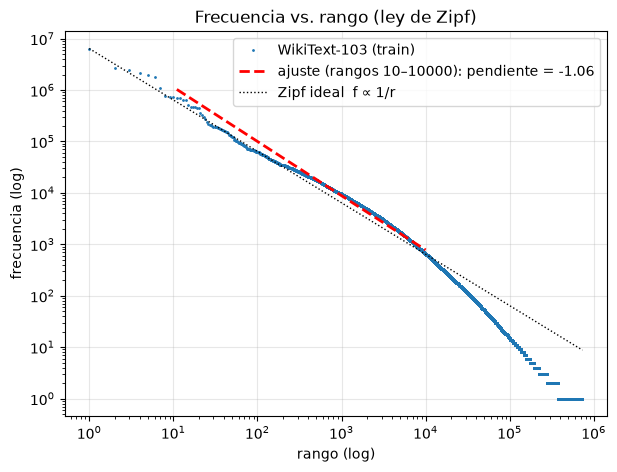

,top-k,% de tokens cubiertos
0,10,24.600440
1,1000,63.909665
2,30000,94.589613


In [8]:
freqs = np.array(sorted(counts.values(), reverse=True), dtype=np.int64)
ranks = np.arange(1, len(freqs) + 1)

# Ajuste lineal en log-log en el tramo "central" (evita la cabeza y la larga cola de hapax)
lo, hi = 10, 10_000
slope, intercept = np.polyfit(np.log10(ranks[lo:hi]), np.log10(freqs[lo:hi]), 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ranks, freqs, ".", ms=2, label="WikiText-103 (train)")
ax.loglog(ranks[lo:hi], 10**intercept * ranks[lo:hi]**slope, "r--", lw=2,
          label=f"ajuste (rangos {lo}–{hi}): pendiente = {slope:.2f}")
ax.loglog(ranks, freqs[0] / ranks, "k:", lw=1, label="Zipf ideal  f ∝ 1/r")
ax.set_xlabel("rango (log)"); ax.set_ylabel("frecuencia (log)")
ax.set_title("Frecuencia vs. rango (ley de Zipf)"); ax.legend(); ax.grid(alpha=.3)
plt.show()

cum = np.cumsum(freqs) / freqs.sum()
cobertura = pd.DataFrame({"top-k": [10, 1_000, 30_000],
                          "% de tokens cubiertos": [100 * cum[k - 1] for k in (10, 1_000, 30_000)]})
cobertura

La relación es aproximadamente lineal en log-log en el tramo central. El ajuste entre los rangos 10 y 10,000 da una pendiente de −1.06, es decir `f(r) ∝ 1/r^α` con α ≈ 1.06, muy cerca del α = 1 de la ley de Zipf clásica. Por tanto, sí se cumple la ley de Zipf de forma aproximada.

Se observan desviaciones en los extremos:
- **Cabeza (rangos ≲ 10):** las palabras más frecuentes quedan algo por encima de la recta ideal 1/r. Las funcionales más comunes aparecen más veces de lo que predice Zipf.
- **Cola (rangos ≳ 10⁴):** la curva cae por debajo de la recta ideal y termina en una "escalera" con frecuencias de 1, 2, 3, …. Esto ocurre porque las frecuencias son enteras y hay una enorme cantidad de palabras con muy pocas apariciones (nombres propios, cifras, términos técnicos, errores). En un corpus finito, la cola no puede seguir la ley de potencias indefinidamente.

**Cobertura del corpus:**

| Top-k palabras | % de tokens cubiertos |
|---|---|
| 10 | 24.6 % |
| 1,000 | 63.9 % |
| 30,000 | 94.6 % |

Las 10 palabras más frecuentes, casi todas funcionales (*the*, *of*, *and*, …), cubren por sí solas cerca de una cuarta parte del texto. Con solo 1,000 palabras se cubre casi dos tercios, y con 30,000 (una fracción muy pequeña del total de tipos, que son cientos de miles) ya se cubre el 94.6 %. El 5.4 % restante está repartido en la cola larga, que concentra la gran mayoría de los tipos distintos.

**Consecuencias para el entrenamiento:**
1. Unas pocas palabras dominan los pares (central, contexto). Esto aporta poca información y encarece cada epoch, lo que justifica el submuestreo de palabras frecuentes.
2. La mayoría de los tipos aparece muy pocas veces, por lo que sus vectores serían ruidosos y de baja calidad. Además, inflarían el vocabulario y los parámetros del modelo, lo que justifica un umbral de `min_count`. Con 94.6 % de cobertura a 30,000 palabras, se puede recortar mucho el vocabulario perdiendo muy pocos tokens.

## 5. Vocabulario con frecuencia mínima (`min_count`)

In [9]:
def vocab_stats(min_count):
    kept = {w: c for w, c in counts.items() if c >= min_count}
    covered = sum(kept.values())
    in_glove = sum(1 for w in kept if w in glove.key_to_index)
    return {"min_count": min_count,
            "tamaño vocab": len(kept) + 2,                      # +<pad>, <unk>
            "% tokens <unk>": 100 * (1 - covered / TOTAL_TOKENS),
            "% tipos descartados": 100 * (1 - len(kept) / len(counts)),
            "% vocab que está en GloVe": 100 * in_glove / len(kept)}

pd.DataFrame([vocab_stats(m) for m in (1, 3, 5, 10, 20, 50, 100)]).round(2)

,min_count,tamaño vocab,% tokens <unk>,% tipos descartados,% vocab que está en GloVe
0,1,734349,0.00,0.00,36.42
1,3,274723,0.66,62.59,70.85
2,5,195028,0.98,73.44,81.72
3,10,128305,1.50,82.53,90.96
4,20,86325,2.17,88.24,95.81
5,50,51407,3.46,93.00,99.06
6,100,33828,4.91,95.39,99.66


**Respuesta:** al subir `min_count` el vocabulario se reduce drásticamente (se pierden muchísimos tipos raros) pero el porcentaje de tokens desconocidos crece muy poco, porque esos tipos suman pocas apariciones. Para este trabajo usaremos `MIN_COUNT = 5` (el valor por defecto de gensim): un buen compromiso entre tamaño del modelo y calidad de los vectores. Justifica aquí tu elección con la tabla.

### Construcción final del vocabulario y conversión a IDs

In [10]:
PAD, UNK = "<pad>", "<unk>"
words = [w for w, c in counts.most_common() if c >= MIN_COUNT]
itos = [PAD, UNK] + words
stoi = {w: i for i, w in enumerate(itos)}
V = len(itos)

cnt = np.zeros(V, dtype=np.int64)
cnt[2:] = [counts[w] for w in words]
cnt[1] = TOTAL_TOKENS - cnt.sum()          # tokens desconocidos (<unk>)
print(f"|V| = {V:,} | % <unk> = {100*cnt[1]/TOTAL_TOKENS:.2f}%")

# Segunda pasada: texto -> IDs. Los <unk> se eliminan del flujo (como Word2Vec).
ids_buf = array("i")
line_lens = []
for toks in iter_clean_lines("train"):
    row = [stoi[t] for t in toks if t in stoi]
    if row:
        ids_buf.extend(row)
        line_lens.append(len(row))

ids = np.frombuffer(ids_buf, dtype=np.int32)
line_lens = np.array(line_lens, dtype=np.int64)
N = ids.size
print(f"Tokens en el flujo de entrenamiento: {N:,} | secuencias (párrafos): {len(line_lens):,}")
print("Ejemplo:", [itos[i] for i in ids[:15]])

|V| = 195,028 | % <unk> = 0.98%


procesando train:   0%|          | 0/1801350 [00:00<?, ?it/s]

Tokens en el flujo de entrenamiento: 83,753,871 | secuencias (párrafos): 859,099
Ejemplo: ['senjō', 'no', 'valkyria', '3', 'unrecorded', 'chronicles', 'japanese', 'lit', 'valkyria', 'of', 'the', 'battlefield', '3', 'commonly', 'referred']


## 6. Submuestreo (subsampling) de palabras frecuentes


In [11]:
def keep_prob(cnt, N, t, variant="paper"):
    f = np.maximum(cnt / N, 1e-12)
    if variant == "paper":
        p = np.sqrt(t / f)
    else:                                  # versión del código C
        p = (np.sqrt(f / t) + 1) * t / f
    return np.clip(p, 0.0, 1.0)

rows = []
for t in (1e-3, 1e-4, 1e-5):
    for variant in ("paper", "word2vec-C"):
        kp = keep_prob(cnt, N, t, "paper" if variant == "paper" else "c")
        r = {"t": t, "fórmula": variant}
        for w in ("the", "of", "and"):
            r[f"% descartado '{w}'"] = 100 * (1 - kp[stoi[w]])
        # fracción esperada del corpus que se conserva
        r["% corpus conservado"] = 100 * (kp[ids].mean() if N < 5e7 else (kp * (cnt / N)).sum())
        rows.append(r)
pd.DataFrame(rows).round(2)

,t,fórmula,% descartado 'the',% descartado 'of',% descartado 'and',% corpus conservado
0,0.0,paper,88.58,82.47,81.55,73.70
1,0.0,word2vec-C,87.28,79.40,78.15,77.96
2,0.0,paper,96.39,94.46,94.17,54.25
3,0.0,word2vec-C,96.26,94.15,93.83,60.49
4,0.0,paper,98.86,98.25,98.16,30.71
5,0.0,word2vec-C,98.84,98.22,98.12,36.34


In [12]:
# Realización estocástica (lo que ocurriría en una epoch) con t = SUBSAMPLING_T
rng = np.random.default_rng(SEED)
kp = keep_prob(cnt, N, SUBSAMPLING_T, "paper")
mask = rng.random(N, dtype=np.float32) < kp[ids]

for w in ("the", "of", "and"):
    sel = ids == stoi[w]
    print(f"'{w}': f = {cnt[stoi[w]]/N:.4f} | descartado teórico = {100*(1-kp[stoi[w]]):.2f}% "
          f"| descartado empírico = {100*(1-mask[sel].mean()):.2f}%")
print(f"Tokens: {N:,} -> {mask.sum():,}  ({100*mask.mean():.1f}% conservado)")

'the': f = 0.0767 | descartado teórico = 98.86% | descartado empírico = 98.86%
'of': f = 0.0325 | descartado teórico = 98.25% | descartado empírico = 98.25%
'and': f = 0.0294 | descartado teórico = 98.16% | descartado empírico = 98.15%
Tokens: 83,753,871 -> 25,698,179  (30.7% conservado)


**¿Por qué ayuda al entrenamiento?**

1. **Eficiencia:** las palabras funcionales (`the`, `of`, `and`) suman una fracción enorme de los tokens y generan millones de pares (central, contexto) muy poco informativos; descartarlas reduce el cómputo por epoch.
2. **Calidad:** `(the, París)` aporta muy poca información sobre `París`, porque `the` coocurre con casi todo; los vectores de palabras frecuentes ya se estabilizan tras pocos ejemplos, así que ver millones más es redundante.
3. **Más peso para palabras raras e informativas:** al quitar parte de las frecuentes, las ventanas se "comprimen" y las palabras de contenido quedan más cerca (contextos efectivos más amplios y más informativos), lo que mejora las representaciones de palabras de frecuencia media y baja.
4. Mikolov et al. reportan aceleraciones de 2×–10× y mejor precisión en analogías.

## 7. Pares (palabra central, contexto) para skip-gram


In [13]:
def n_pairs(lengths, C):
    L = np.asarray(lengths, dtype=np.int64)
    d = np.minimum(C, L - 1)
    return int((2 * (d * L - d * (d + 1) // 2)).sum())

def skipgram_pairs(seq, C):
    """Generador explícito de pares (central, contexto) de una secuencia de IDs."""
    n = len(seq)
    for i in range(n):
        for j in range(max(0, i - C), min(n, i + C + 1)):
            if j != i:
                yield seq[i], seq[j]

# Demo con una oración
demo = [stoi[w] for w in "the quick brown fox jumps over the lazy dog".split() if w in stoi]
print([(itos[a], itos[b]) for a, b in skipgram_pairs(demo, 2)][:12], "...")

# Verificación: fórmula cerrada vs. generador en las primeras 2,000 secuencias
offs = np.concatenate([[0], np.cumsum(line_lens)])
check = sum(sum(1 for _ in skipgram_pairs(ids[offs[k]:offs[k+1]].tolist(), WINDOW)) for k in range(2000))
assert check == n_pairs(line_lens[:2000], WINDOW), "la fórmula no coincide con el generador"
print("Verificación OK:", check, "pares en 2,000 secuencias")

[('the', 'quick'), ('the', 'brown'), ('quick', 'the'), ('quick', 'brown'), ('quick', 'fox'), ('brown', 'the'), ('brown', 'quick'), ('brown', 'fox'), ('brown', 'jumps'), ('fox', 'quick'), ('fox', 'brown'), ('fox', 'jumps')] ...
Verificación OK: 1917496 pares en 2,000 secuencias


In [14]:
pairs_before = n_pairs(line_lens, WINDOW)

line_of = np.repeat(np.arange(len(line_lens), dtype=np.int32), line_lens)
new_lens = np.bincount(line_of[mask], minlength=len(line_lens))
pairs_after = n_pairs(new_lens, WINDOW)
del line_of

resumen = pd.DataFrame({
    "": ["sin submuestreo", f"con submuestreo (t={SUBSAMPLING_T:g})"],
    "tokens": [N, int(mask.sum())],
    f"pares por epoch (C={WINDOW})": [pairs_before, pairs_after],
})
resumen["reducción de pares"] = ["—", f"{100*(1 - pairs_after/pairs_before):.1f}%"]
resumen

,,tokens,pares por epoch (C=5),reducción de pares
0,sin submuestreo,83753871,812165972,—
1,con submuestreo (t=1e-05),25698179,232429016,71.4%


In [15]:
# Sensibilidad al umbral t (una realización por valor)
rows = []
for t in (1e-3, 1e-4, 1e-5):
    kp_t = keep_prob(cnt, N, t, "paper")
    m = np.random.default_rng(SEED).random(N, dtype=np.float32) < kp_t[ids]
    lo_ = np.repeat(np.arange(len(line_lens), dtype=np.int32), line_lens)
    nl = np.bincount(lo_[m], minlength=len(line_lens)); del lo_
    rows.append({"t": t, "tokens conservados": int(m.sum()), f"pares/epoch (C={WINDOW})": n_pairs(nl, WINDOW)})
pd.DataFrame(rows)

,t,tokens conservados,pares/epoch (C=5)
0,0.00100,61461782,589292214
1,0.00010,45350615,428331958
2,0.00001,25698179,232429016


**Notas**

- El submuestreo se aplica de forma aleatoria en cada epoch, por lo que el número exacto de pares varía ligeramente entre epochs; aquí reportamos una realización (la esperanza es casi idéntica por el tamaño del corpus).
- Si se usa ventana dinámica como en Word2Vec (tamaño efectivo muestreado uniformemente en `[1, C]`), el número esperado de pares es aproximadamente el que resulta de una ventana de `(C+1)/2`.
- Cada par positivo se acompaña de `k` negativos en negative sampling, así que el costo real por epoch es ≈ `(1 + k) ×` el número de pares.
- Al eliminar tokens frecuentes *antes* de abrir la ventana, el contexto efectivo se extiende más allá de `C` palabras originales.